In [ ]:
import torch.optim as optim
from random import randint
import utils
import time

In [ ]:
device = torch.device("cuda")
print(device)

cuda


In [ ]:
torch.cuda.get_device_name()

'Tesla T4'

In [ ]:
train_data = torch.load('./data/cifar/train_data.pt')
train_label = torch.load('./data/cifar/train_label.pt')
test_data = torch.load('./data/cifar/test_data.pt')
test_label = torch.load('./data/cifar/test_label.pt')

print(train_data.size())
print(test_data.size())

torch.Size([50000, 3, 32, 32])
torch.Size([10000, 3, 32, 32])


In [ ]:
class BasicBlock(nn.Module):

    def __init__(self, num_channels):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(num_channels, affine=True)
        self.conv1 = nn.Conv2d(num_channels, num_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(num_channels, affine=True)
        self.conv2 = nn.Conv2d(num_channels, num_channels, kernel_size=3, stride=1, padding=1, bias=False)

    def forward(self, x):
        y = self.bn1(x)
        y = F.relu(y)
        y = self.conv1(y)
        y = self.bn2(y)
        y = F.relu(y)
        z = self.conv2(y)
        output = x + z     # residual connection
        return output

In [ ]:
class BridgeBlock(nn.Module):

    def __init__(self, num_channels):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(num_channels, affine=True)
        self.conv1 = nn.Conv2d(num_channels, 2*num_channels,
                               kernel_size=3, stride=2, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(2*num_channels, affine=True)
        self.conv2 = nn.Conv2d(2*num_channels, 2*num_channels,
                               kernel_size=3, stride=1, padding=1, bias=False)

    def forward(self, x):
        y = self.bn1(x)
        y = F.relu(y)
        y = self.conv1(y)   # downsample: H,W --> H/2,W/2; channels: C --> 2C
        y = self.bn2(y)
        y = F.relu(y)
        z = self.conv2(y)
        return z            # no skip connection

In [ ]:
class ResNet(nn.Module):

    def __init__(self, n):   # n = number of basic blocks per stage (6n+6 layers)
        super().__init__()

        # first conv
        self.first_layer = nn.Conv2d(3, 16,
                                     kernel_size=3, stride=1, padding=1, bias=False)

        # stage 1: n basic blocks, 16 channels
        list1 = []
        for i in range(n):
            list1.append(BasicBlock(16))
        self.list_stage1 = nn.ModuleList(list1)

        # bridge 1: 16 --> 32, 32x32 --> 16x16
        self.bridge1 = BridgeBlock(16)

        # stage 2: n basic blocks, 32 channels
        list2 = []
        for i in range(n):
            list2.append(BasicBlock(32))
        self.list_stage2 = nn.ModuleList(list2)

        # bridge 2: 32 --> 64, 16x16 --> 8x8
        self.bridge2 = BridgeBlock(32)

        # stage 3: n basic blocks, 64 channels
        list3 = []
        for i in range(n):
            list3.append(BasicBlock(64))
        self.list_stage3 = nn.ModuleList(list3)

        self.avgpool = nn.AvgPool2d(kernel_size=8)   # average pooling

        self.last_layer = nn.Linear(64, 10, bias=False)   # last linear layer

    def forward(self, x):
        # x: bs x 3 x 32 x 32
        x = self.first_layer(x)              # bs x 16 x 32 x 32

        for block in self.list_stage1:       # stage 1: bs x 16 x 32 x 32
            x = block(x)

        x = self.bridge1(x)                  # bs x 32 x 16 x 16

        for block in self.list_stage2:       # stage 2: bs x 32 x 16 x 16
            x = block(x)

        x = self.bridge2(x)                  # bs x 64 x 8 x 8

        for block in self.list_stage3:       # stage 3: bs x 64 x 8 x 8
            x = block(x)

        x = self.avgpool(x)                  # bs x 64 x 1 x 1
        x = x.view(x.size(0), 64)            # bs x 64

        scores = self.last_layer(x)          # bs x 10
        return scores

In [ ]:
n = 7
net = ResNet(n)
net = net.to(device)

print(net)
utils.display_num_param(net)

ResNet(
  (first_layer): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (list_stage1): ModuleList(
    (0-6): 7 x BasicBlock(
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
  )
  (bridge1): BridgeBlock(
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (list_stage2): ModuleList(
    (0-6): 7 x BasicBlock(
      (bn1

In [ ]:
criterion = nn.CrossEntropyLoss()
my_lr = 0.05
bs = 150

In [ ]:
mean = train_data.mean().to(device)
std = train_data.std().to(device)

In [ ]:
def eval_on_test_set():
    net.eval()
    running_error=0
    num_batches=0

    with torch.no_grad():
        for i in range(0,10000,bs):

            minibatch_data = test_data[i:i+bs]
            minibatch_label = test_label[i:i+bs]

            minibatch_data=minibatch_data.to(device)
            minibatch_label=minibatch_label.to(device)

            inputs = (minibatch_data - mean)/std

            scores = net(inputs)

            error = utils.get_error( scores , minibatch_label)

            running_error += error.item()

            num_batches += 1

    total_error = running_error/num_batches
    print( 'error rate on test set =', total_error*100 ,'percent')

In [ ]:
start = time.time()

for epoch in range(80):

    if epoch == 50:
        my_lr = my_lr/10.0

    optimizer=torch.optim.SGD(net.parameters(), lr=my_lr, momentum=0.9, weight_decay=0.0005)

    net.train()
    running_loss=0
    running_error=0
    num_batches=0

    shuffled_indices = torch.randperm(50000)

    for count in range(0,50000,bs):

        optimizer.zero_grad()

        indices = shuffled_indices[count:count+bs]
        minibatch_data = train_data[indices]      # bs x 3 x 32 x 32
        minibatch_label = train_label[indices]    # bs

        minibatch_data = minibatch_data.to(device)
        minibatch_label = minibatch_label.to(device)

        # horizontal flip + cat
        flipped_dat = torch.flip(minibatch_data, dims=(3,))
        aug_dat = torch.cat([minibatch_data, flipped_dat], dim=0)          # 2*bs x 3 x 32 x 32
        aug_label = torch.cat([minibatch_label, minibatch_label], dim=0)   # 2*bs

        inputs = (aug_dat - mean)/std
        targets = aug_label

        scores = net(inputs)
        loss = criterion(scores, targets)

        loss.backward()
        optimizer.step()

        num_batches += 1

        with torch.no_grad():

            running_loss += loss.item()
            error = utils.get_error(scores, targets)
            running_error += error.item()

    total_loss = running_loss/num_batches
    total_error = running_error/num_batches
    elapsed_time = time.time() - start

    if epoch % 10 == 0:
        print(' ')
        print('epoch=',epoch, '\t time=', elapsed_time,
              '\t loss=', total_loss , '\t error=', total_error*100 ,'percent')
        eval_on_test_set()

 
epoch= 0 	 time= 71.94692063331604 	 loss= 1.5638561491480845 	 error= 58.42614659292256 percent
error rate on test set = 51.09452525181557 percent
 
epoch= 10 	 time= 759.0615530014038 	 loss= 0.34159798875540315 	 error= 11.749498894114694 percent
error rate on test set = 23.04477478141215 percent
 
epoch= 20 	 time= 1446.7093136310577 	 loss= 0.2398375129092953 	 error= 8.357283365940619 percent
error rate on test set = 17.437808994037002 percent
 
epoch= 30 	 time= 2134.0341992378235 	 loss= 0.20248191092096404 	 error= 7.127742353313697 percent
error rate on test set = 26.208953537158113 percent
 
epoch= 40 	 time= 2821.7306389808655 	 loss= 0.17693431744586208 	 error= 6.218560602136715 percent
error rate on test set = 17.477610129029003 percent
 
epoch= 50 	 time= 3509.38729596138 	 loss= 0.0605132485834692 	 error= 1.8652677892924783 percent
error rate on test set = 10.174127390135581 percent
 
epoch= 60 	 time= 4196.7367906570435 	 loss= 0.0030597570888324455 	 error= 0.0189

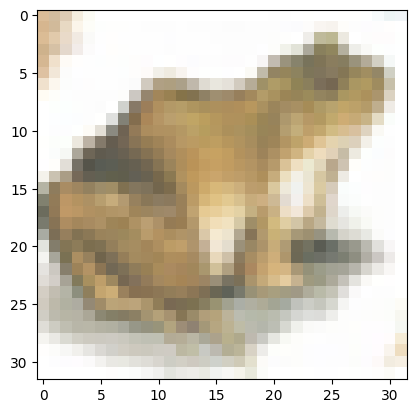

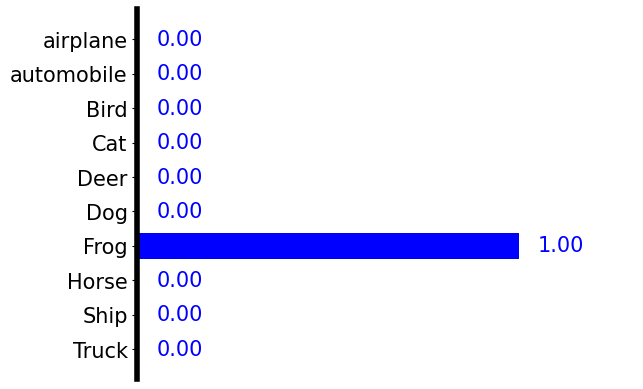

In [ ]:
# choose a picture at random
idx=randint(0, 10000-1)
im=test_data[idx]

# display the picture
utils.show(im)

# send to device, rescale, and view as a batch of 1
im = im.to(device)
im= (im-mean) / std
im=im.view(1,3,32,32)

# feed it to the net and display the confidence scores
with torch.no_grad():
    scores = net(im)
    probs = F.softmax(scores, dim=1)
utils.show_prob_cifar(probs.cpu())